# Policy-Aware RAG Evaluation Analysis

This notebook analyzes the evaluation artifact loaded by `RESULTS_PATH`: `evaluation_results_2026-09-09T17-15-45Z.json`. It summarizes policy outcomes, end-to-end latency, instrumented pipeline latency, token estimates, per-step telemetry, and optional RAGAS quality metrics.

## Measurement Scope

- `http_latency_ms` is the client-side wall-clock duration of the complete `POST /api/rag` request.
- `total_step_latency_ms` is the sum of the named audit steps returned for that request, including intent validation, context retrieval, spokesperson validation, and output redaction when those steps are available.
- The difference between these latency measures includes work outside the step timers, such as model initialization, embedding generation, runtime overhead, network activity, and audit persistence.
- Token counts are estimates generated by the evaluation harness using a four-characters-per-token heuristic; they are not provider billing or tokenizer measurements.

## Interpretation

Pass rate is calculated from the evaluator's `passed` field and grouped by `case_type`. A policy denial is a passing result when denial is the expected outcome. Requests that fail before producing a valid response are not converted into passes.

Step telemetry is available only when the Function App writes the request-level audit record and the evaluator can retrieve it. Missing audit records or failed requests may therefore produce no step-level observations.

The chart cell exports publication-resolution PNG and SVG figures to `tests/performance_evaluation/figures/`. When answer-bearing records and compatible model configuration are available, the RAGAS cells also calculate answer relevancy and faithfulness, plus reference-based metrics when reference answers are present.

In [9]:
import json
import os
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv, find_dotenv

try:
    from datasets import Dataset
    from langchain_openai import ChatOpenAI, OpenAIEmbeddings
    from ragas import evaluate
    from ragas.embeddings import LangchainEmbeddingsWrapper
    from ragas.llms import LangchainLLMWrapper
    from ragas.metrics import AnswerRelevancy, ContextPrecision, ContextRecall, Faithfulness

    load_dotenv(find_dotenv())
    foundry_endpoint = os.getenv('FOUNDRY_ENDPOINT')
    foundry_api_key = os.getenv('FOUNDRY_API_KEY')
    foundry_chat_model = os.getenv('FOUNDRY_CHAT_MODEL')
    foundry_embedding_model = os.getenv('FOUNDRY_EMBEDDING_MODEL')

    if not foundry_endpoint or not foundry_api_key:
        raise ValueError('FOUNDRY_ENDPOINT and FOUNDRY_API_KEY must be configured')

    foundry_llm = LangchainLLMWrapper(
        ChatOpenAI(
            model=foundry_chat_model,
            api_key=foundry_api_key,
            base_url=foundry_endpoint,
            temperature=0,
        ),
        bypass_n=True,
    )
    foundry_embeddings = LangchainEmbeddingsWrapper(
        OpenAIEmbeddings(
            model=foundry_embedding_model,
            api_key=foundry_api_key,
            base_url=foundry_endpoint,
        )
    )
    ragas_metrics = [
        AnswerRelevancy(
            llm=foundry_llm,
            embeddings=foundry_embeddings,
            strictness=3,
        ),
        Faithfulness(llm=foundry_llm),
    ]
    reference_metrics = [
        ContextPrecision(llm=foundry_llm),
        ContextRecall(llm=foundry_llm),
    ]
    HAS_RAGAS = True
except Exception as exc:
    HAS_RAGAS = False
    print(f'RAGAS metrics unavailable: {exc}')

RESULTS_PATH = ("evaluation_results_2026-09-09T17-15-45Z.json")
print(f"Results file: {RESULTS_PATH}")
print(f"Has RAGAS: {HAS_RAGAS}")

C:\Users\dillo\AppData\Local\Temp\ipykernel_31360\686697673.py:14: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerRelevancy
  from ragas.metrics import AnswerRelevancy, ContextPrecision, ContextRecall, Faithfulness
C:\Users\dillo\AppData\Local\Temp\ipykernel_31360\686697673.py:14: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextPrecision
  from ragas.metrics import AnswerRelevancy, ContextPrecision, ContextRecall, Faithfulness
C:\Users\dillo\AppData\Local\Temp\ipykernel_31360\686697673.py:14: DeprecationWarning: Importing ContextRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from rag

Results file: evaluation_results_2026-09-09T17-15-45Z.json
Has RAGAS: True


C:\Users\dillo\AppData\Local\Temp\ipykernel_31360\686697673.py:34: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  foundry_embeddings = LangchainEmbeddingsWrapper(


In [10]:
def load_results(path):
    payload = json.loads(Path(path).read_text(encoding='utf-8'))
    return payload.get('results', [])

records = load_results(RESULTS_PATH)
df = pd.DataFrame(records)
display(df[['case_type', 'status_code', 'expected_outcome', 'actual_outcome', 'passed', 'http_latency_ms', 'total_step_latency_ms']].head())


,case_type,status_code,expected_outcome,actual_outcome,passed,http_latency_ms,total_step_latency_ms
0,allow_observer_metadata,200,allow,allow,True,28493,7798.178
1,allow_observer_routing,200,allow,allow,True,27946,8223.782
2,allow_observer_triage,200,allow,allow,True,27480,7366.084
3,allow_support_customer,200,allow,allow,True,30121,11036.641
4,allow_support_case,200,allow,allow,True,31359,10330.026


In [11]:
step_rows = []
for row in df.itertuples():
    for step in getattr(row, 'step_metrics', []):
        step_rows.append({
            'case_type': row.case_type,
            'stepName': step.get('stepName'),
            'executionStatus': step.get('executionStatus'),
            'latency_ms': step.get('latency_ms', 0),
            'query_tokens': step.get('query_tokens', 0),
            'answer_tokens': step.get('answer_tokens', 0),
            'document_count': step.get('document_count'),
        })

steps_df = pd.DataFrame(step_rows)
display(steps_df.groupby('stepName').agg(step_count=('stepName', 'size'), avg_latency_ms=('latency_ms', 'mean')).sort_values('avg_latency_ms', ascending=False))


,step_count,avg_latency_ms
stepName,,
SpokespersonValidation,23,5232.315783
ContextRetrieval,23,3088.543652
IntentValidation,25,20.068680
OutputRedaction,23,0.001478


In [12]:
token_counts = pd.json_normalize(df.get('token_counts', pd.Series(dtype=object))).fillna(0)
for column in ('question_tokens', 'answer_tokens', 'source_tokens'):
    if column not in token_counts:
        token_counts[column] = 0
df = df.reset_index(drop=True)
df['question_tokens'] = token_counts['question_tokens'].astype(float)
df['answer_tokens'] = token_counts['answer_tokens'].astype(float)
df['source_tokens'] = token_counts['source_tokens'].astype(float)
df['total_tokens'] = df[['question_tokens', 'answer_tokens', 'source_tokens']].sum(axis=1)

summary = df.groupby('case_type').agg(
    total=('question', 'size'),
    passed=('passed', 'sum'),
    pass_rate=('passed', 'mean'),
    avg_http_latency_ms=('http_latency_ms', 'mean'),
    avg_step_latency_ms=('total_step_latency_ms', 'mean'),
    avg_question_tokens=('question_tokens', 'mean'),
    avg_answer_tokens=('answer_tokens', 'mean'),
    avg_source_tokens=('source_tokens', 'mean'),
    avg_total_tokens=('total_tokens', 'mean'),
).reset_index()
summary['pass_rate'] = summary['pass_rate'].round(3)
summary['avg_http_latency_ms'] = summary['avg_http_latency_ms'].round(1)
summary['avg_step_latency_ms'] = summary['avg_step_latency_ms'].round(1)
for column in ('avg_question_tokens', 'avg_answer_tokens', 'avg_source_tokens', 'avg_total_tokens'):
    summary[column] = summary[column].round(1)
display(summary.sort_values('pass_rate'))

,case_type,total,passed,pass_rate,avg_http_latency_ms,avg_step_latency_ms,avg_question_tokens,avg_answer_tokens,avg_source_tokens,avg_total_tokens
10,allow_support_incident,2,1,0.5,22943.5,8316.9,18.5,321.5,65.5,405.5
0,allow_admin_full_access,2,2,1.0,15661.0,6595.7,18.5,192.5,56.0,267.0
2,allow_observer_routing,2,2,1.0,21732.5,7954.8,16.5,344.0,63.0,423.5
1,allow_observer_metadata,3,3,1.0,19256.3,7916.9,15.0,418.3,58.0,491.3
4,allow_privacy_compliance,2,2,1.0,24371.0,9742.9,17.0,476.0,57.5,550.5
5,allow_privacy_fraud,2,2,1.0,23495.0,8876.7,15.5,462.0,60.5,538.0
6,allow_privacy_privacy,2,2,1.0,16004.5,6909.9,16.5,296.0,59.0,371.5
3,allow_observer_triage,2,2,1.0,21427.5,7395.9,17.5,323.5,59.0,400.0
7,allow_privacy_security,2,2,1.0,15861.5,6650.9,18.5,241.0,60.5,320.0
8,allow_support_case,2,2,1.0,25782.5,12152.8,17.5,367.0,58.0,442.5


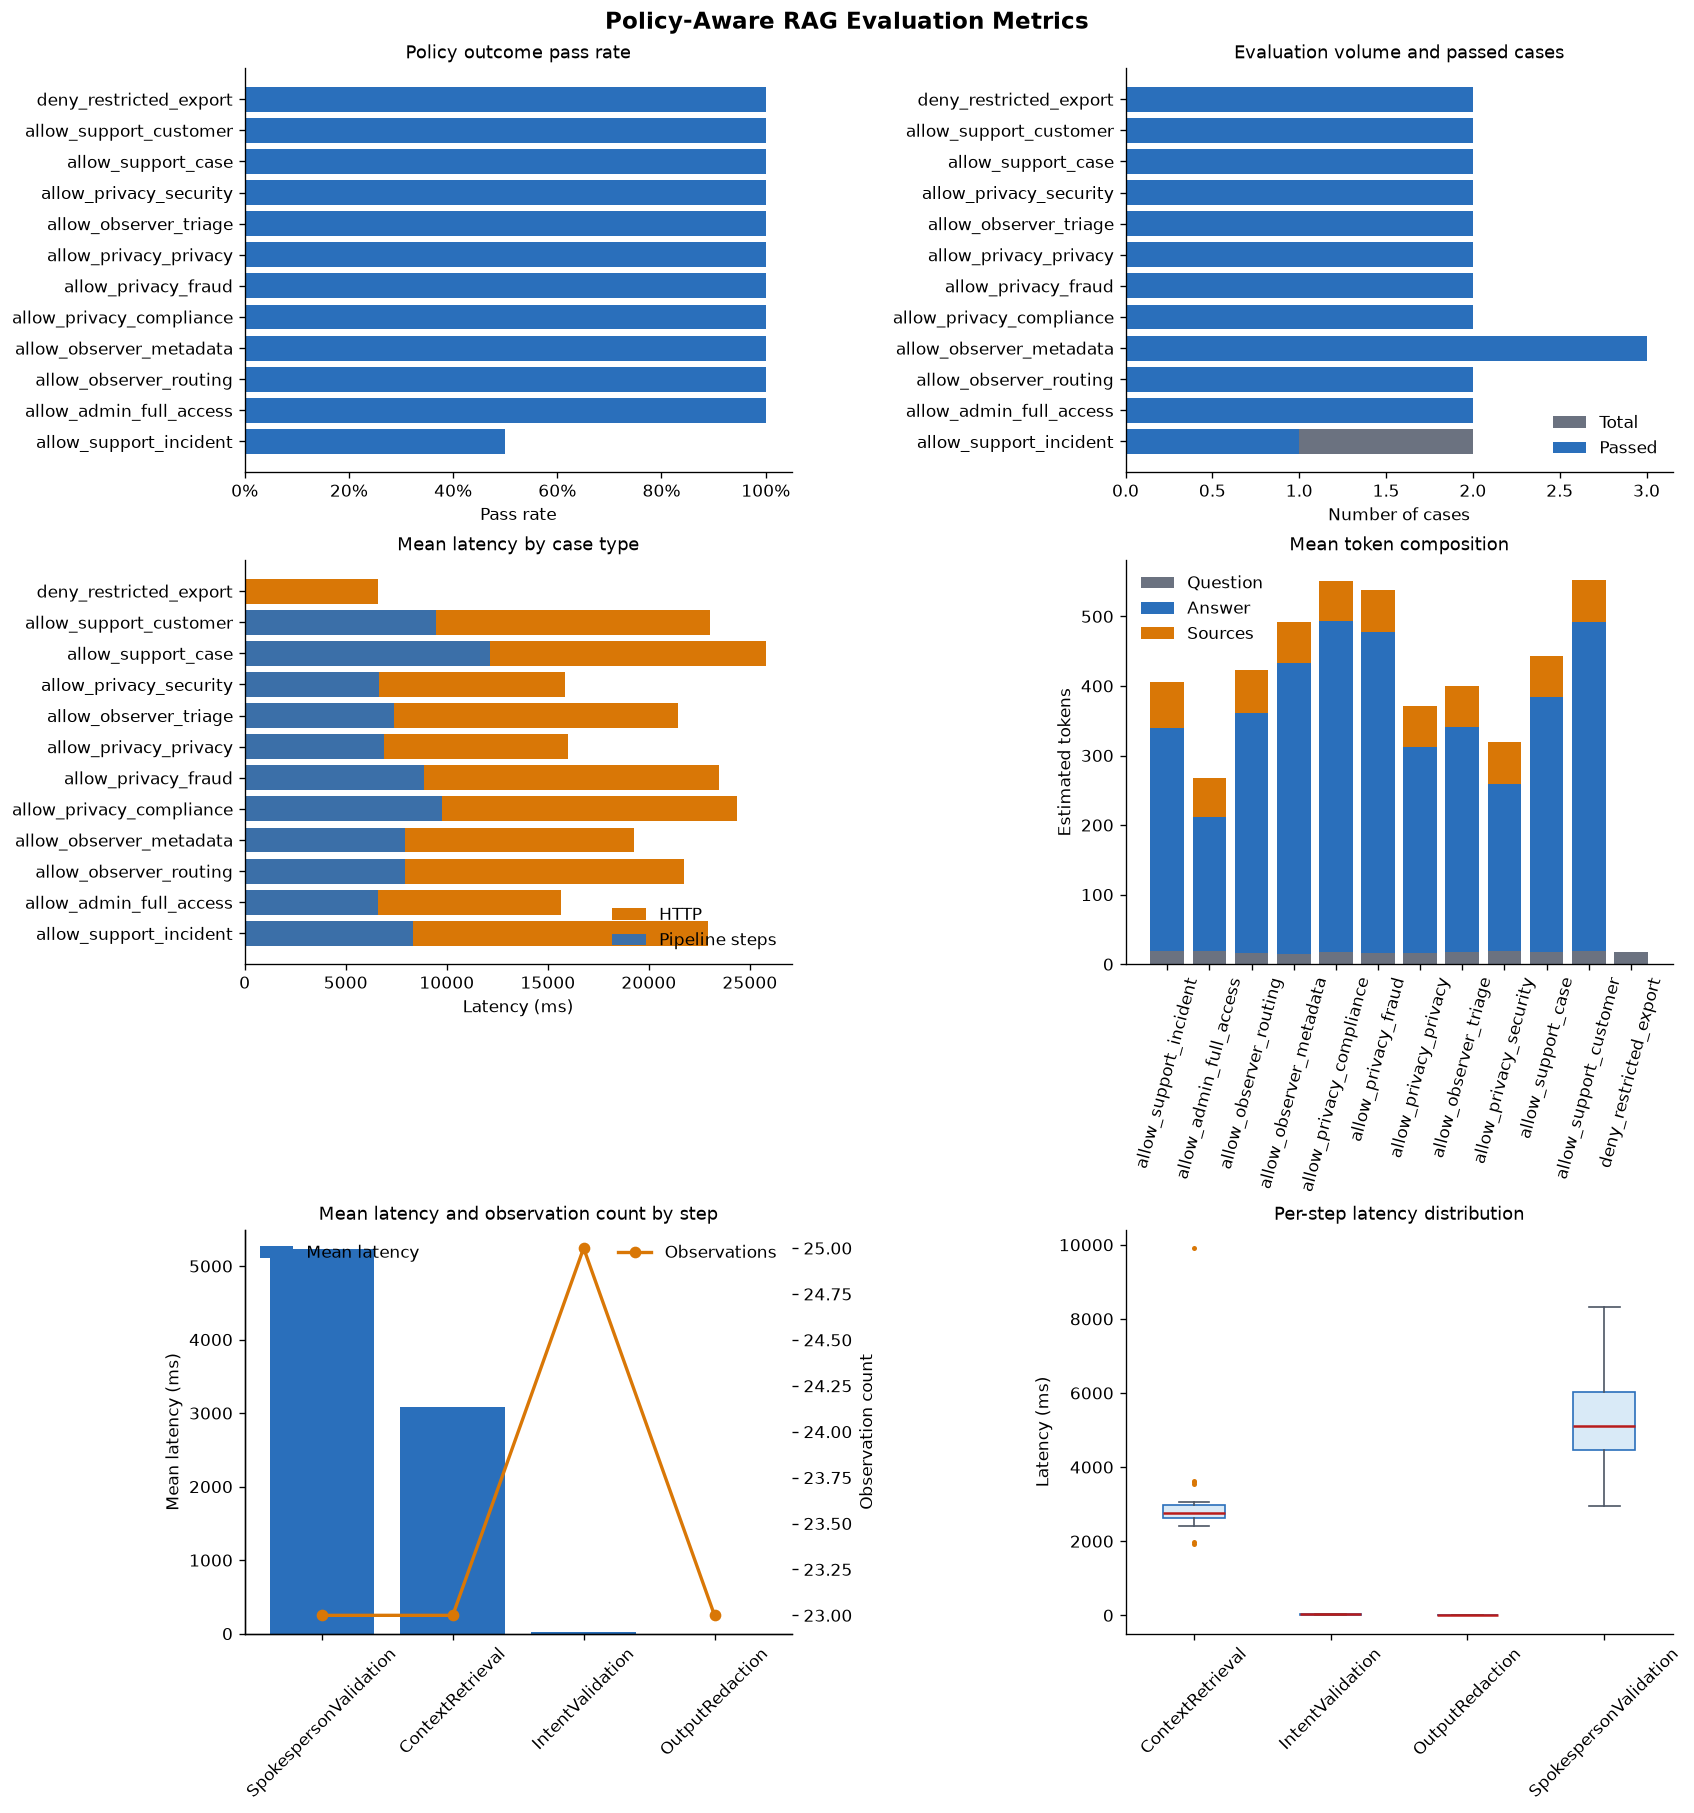

Saved figures to C:\Users\dillo\Source\Repos\PolicyAwareRAG\tests\performance_evaluation\figures


In [13]:
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

plot_summary = summary.sort_values('pass_rate').copy()
fig, axes = plt.subplots(3, 2, figsize=(14, 15), constrained_layout=True)

axes[0, 0].barh(plot_summary['case_type'], plot_summary['pass_rate'], color='#2A6FBB')
axes[0, 0].set_title('Policy outcome pass rate')
axes[0, 0].set_xlabel('Pass rate')
axes[0, 0].set_xlim(0, 1.05)
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.0%}'))

axes[0, 1].barh(plot_summary['case_type'], plot_summary['total'], color='#6B7280', label='Total')
axes[0, 1].barh(plot_summary['case_type'], plot_summary['passed'], color='#2A6FBB', label='Passed')
axes[0, 1].set_title('Evaluation volume and passed cases')
axes[0, 1].set_xlabel('Number of cases')
axes[0, 1].legend(frameon=False, loc='lower right')

axes[1, 0].barh(plot_summary['case_type'], plot_summary['avg_http_latency_ms'], color='#D97706', label='HTTP')
axes[1, 0].barh(plot_summary['case_type'], plot_summary['avg_step_latency_ms'], color='#2A6FBB', alpha=0.9, label='Pipeline steps')
axes[1, 0].set_title('Mean latency by case type')
axes[1, 0].set_xlabel('Latency (ms)')
axes[1, 0].legend(frameon=False, loc='lower right')

token_columns = ['avg_question_tokens', 'avg_answer_tokens', 'avg_source_tokens']
token_labels = ['Question', 'Answer', 'Sources']
token_colors = ['#6B7280', '#2A6FBB', '#D97706']
left = pd.Series(0.0, index=plot_summary.index)
for column, label, color in zip(token_columns, token_labels, token_colors):
    axes[1, 1].bar(plot_summary['case_type'], plot_summary[column], bottom=left, label=label, color=color)
    left = left + plot_summary[column]
axes[1, 1].set_title('Mean token composition')
axes[1, 1].set_ylabel('Estimated tokens')
axes[1, 1].tick_params(axis='x', rotation=75)
axes[1, 1].legend(frameon=False, loc='upper left')

if not steps_df.empty:
    step_summary = steps_df.groupby('stepName').agg(
        step_count=('stepName', 'size'),
        avg_latency_ms=('latency_ms', 'mean'),
    ).sort_values('avg_latency_ms', ascending=False)
    step_axis = axes[2, 0]
    step_axis.bar(step_summary.index, step_summary['avg_latency_ms'], color='#2A6FBB')
    step_axis.set_title('Mean latency and observation count by step')
    step_axis.set_ylabel('Mean latency (ms)')
    step_axis.tick_params(axis='x', rotation=45)
    count_axis = step_axis.twinx()
    count_axis.plot(step_summary.index, step_summary['step_count'], color='#D97706', marker='o', linewidth=2, label='Observations')
    count_axis.set_ylabel('Observation count')
    count_axis.spines.top.set_visible(False)
    step_axis.legend(['Mean latency'], frameon=False, loc='upper left')
    count_axis.legend(frameon=False, loc='upper right')
else:
    axes[2, 0].text(0.5, 0.5, 'No step telemetry available', ha='center', va='center')
    axes[2, 0].set_axis_off()

if not steps_df.empty:
    step_latency = steps_df.groupby('stepName')['latency_ms'].apply(list)
    axes[2, 1].boxplot(
        step_latency.tolist(),
        tick_labels=step_latency.index,
        patch_artist=True,
        boxprops={'facecolor': '#D9EAF7', 'edgecolor': '#2A6FBB'},
        medianprops={'color': '#B91C1C', 'linewidth': 1.5},
        whiskerprops={'color': '#4B5563'},
        capprops={'color': '#4B5563'},
        flierprops={'marker': 'o', 'markerfacecolor': '#D97706', 'markersize': 3, 'markeredgecolor': 'none'},
    )
    axes[2, 1].set_title('Per-step latency distribution')
    axes[2, 1].set_ylabel('Latency (ms)')
    axes[2, 1].tick_params(axis='x', rotation=45)
else:
    axes[2, 1].text(0.5, 0.5, 'No step telemetry available', ha='center', va='center')
    axes[2, 1].set_axis_off()

fig.suptitle('Policy-Aware RAG Evaluation Metrics', fontsize=14, fontweight='bold')
fig.savefig(FIGURES_DIR / 'evaluation_metrics.png', bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'evaluation_metrics.svg', bbox_inches='tight')
plt.show()
print(f'Saved figures to {FIGURES_DIR.resolve()}')

In [14]:
if HAS_RAGAS:
    ragas_rows = []
    for row in df.itertuples():
        answer = str(row.response.get('answer', '') if isinstance(row.response, dict) else '')
        sources = row.response.get('sources', []) if isinstance(row.response, dict) else []
        if not answer:
            continue
        dataset = Dataset.from_dict({
            'question': [row.question],
            'answer': [answer],
            'contexts': [[str(item) for item in sources]],
        })
        scores = evaluate(dataset, metrics=ragas_metrics)
        score_values = scores.scores[0]
        ragas_rows.append({
            'case_type': row.case_type,
            **{k: float(v) for k, v in score_values.items() if isinstance(v, (int, float))},
        })
    if ragas_rows:
        ragas_df = pd.DataFrame(ragas_rows)
        display(ragas_df.groupby('case_type').mean(numeric_only=True).round(3))
    else:
        print('No answer-bearing records are available for RAGAS evaluation.')
else:
    print('RAGAS is not installed or Azure Foundry settings are unavailable; showing proxy pass-rate summary instead.')
    display(df.groupby('case_type').agg(pass_rate=('passed', 'mean')).round(3))

Evaluating: 100%|██████████| 2/2 [00:29<00:00, 14.96s/it]


,answer_relevancy,faithfulness
case_type,,
allow_admin_full_access,0.420,0.417
allow_observer_metadata,0.781,0.289
allow_observer_routing,0.683,0.118
allow_observer_triage,0.680,0.000
allow_privacy_compliance,0.914,0.263
allow_privacy_fraud,0.750,0.380
allow_privacy_privacy,0.871,0.521
allow_privacy_security,0.366,0.322
allow_support_case,0.544,0.218


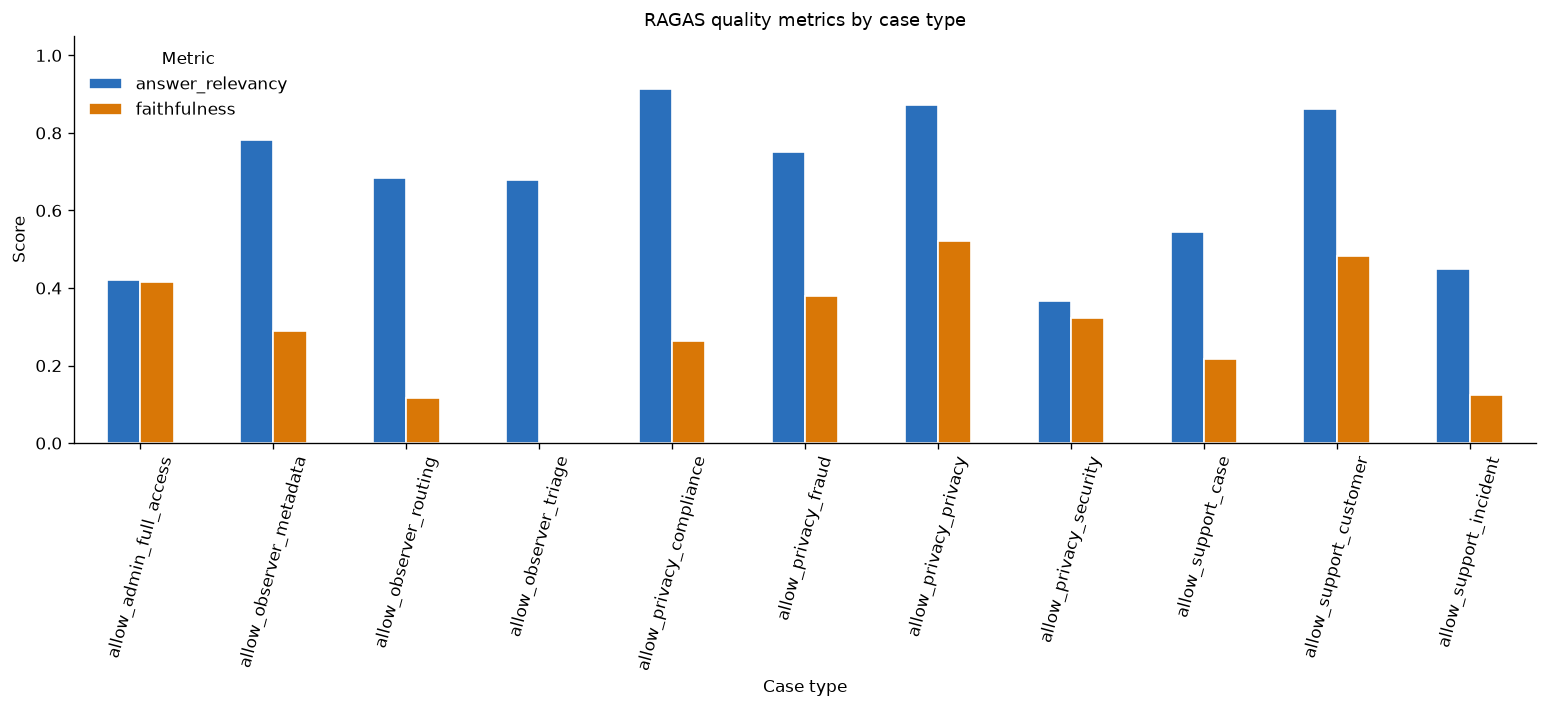

Saved RAGAS figures to C:\Users\dillo\Source\Repos\PolicyAwareRAG\tests\performance_evaluation\figures


In [15]:
if 'ragas_df' in globals() and not ragas_df.empty:
    ragas_plot = ragas_df.groupby('case_type').mean(numeric_only=True).sort_index()
    ax = ragas_plot.plot(
        kind='bar',
        figsize=(13, 6),
        color=['#2A6FBB', '#D97706', '#6B7280', '#B91C1C'],
        edgecolor='white',
    )
    ax.set_title('RAGAS quality metrics by case type')
    ax.set_xlabel('Case type')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=75)
    ax.legend(title='Metric', frameon=False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f'{value:.1f}'))
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'ragas_metrics.png', dpi=300, bbox_inches='tight')
    plt.savefig(FIGURES_DIR / 'ragas_metrics.svg', bbox_inches='tight')
    plt.show()
    print(f'Saved RAGAS figures to {FIGURES_DIR.resolve()}')
else:
    print('No RAGAS results available for charting.')